# 08 — MLflow Experiment Tracking

This notebook connects to the project's **SQLite MLflow store** (`mlflow.db`) and visualises
the full experiment: run metadata, hyperparameters, validation vs test performance, and the
champion model selection.

**Prerequisites:** run `python run_pipeline.py` (phases 3 + 4) at least once.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

ROOT = Path("../")
sys.path.insert(0, str(ROOT))

import mlflow
from mlflow.tracking import MlflowClient

DB_URI = f"sqlite:///{ROOT / 'mlflow.db'}"
mlflow.set_tracking_uri(DB_URI)
client = MlflowClient()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13})
print("Connected to:", DB_URI)

Connected to: sqlite:///../mlflow.db


## 1 · Load all runs

In [2]:
exp = client.get_experiment_by_name("lte_handover_prediction")
if exp is None:
    raise RuntimeError("Experiment not found — run the pipeline first.")

runs = client.search_runs(
    experiment_ids=[exp.experiment_id],
    order_by=["metrics.test_roc_auc DESC"],
)

rows = []
for r in runs:
    rows.append({
        "Model":        r.data.tags.get("mlflow.runName", r.info.run_id[:8]),
        "val_f1":       r.data.metrics.get("val_f1"),
        "test_f1":      r.data.metrics.get("test_f1"),
        "test_auc":     r.data.metrics.get("test_roc_auc"),
        "test_prec":    r.data.metrics.get("test_precision"),
        "test_recall":  r.data.metrics.get("test_recall"),
        "run_id":       r.info.run_id[:8],
        "params":       r.data.params,
    })

df = pd.DataFrame(rows)
display_cols = ["Model","val_f1","test_f1","test_auc","test_prec","test_recall"]
df[display_cols].style \
    .highlight_max(subset=["val_f1","test_f1","test_auc","test_prec","test_recall"],
                   color="#c6efce") \
    .format({c: "{:.4f}" for c in display_cols[1:]}) \
    .set_caption("All MLflow runs — sorted by test ROC-AUC")

,Model,val_f1,test_f1,test_auc,test_prec,test_recall
0,stacking_ensemble,0.4179,0.4199,0.9119,0.5157,0.3541
1,xgboost,0.5351,0.5237,0.9116,0.4176,0.7021
2,random_forest,0.5240,0.5191,0.9089,0.4058,0.7202
3,logistic_regression,0.4974,0.4595,0.8942,0.3145,0.8523
4,lstm,0.5015,0.4559,0.8806,0.3171,0.8108
5,gru,0.5125,0.4605,0.8775,0.3203,0.8189


## 2 · Val F1 vs Test F1 — did validation generalise?

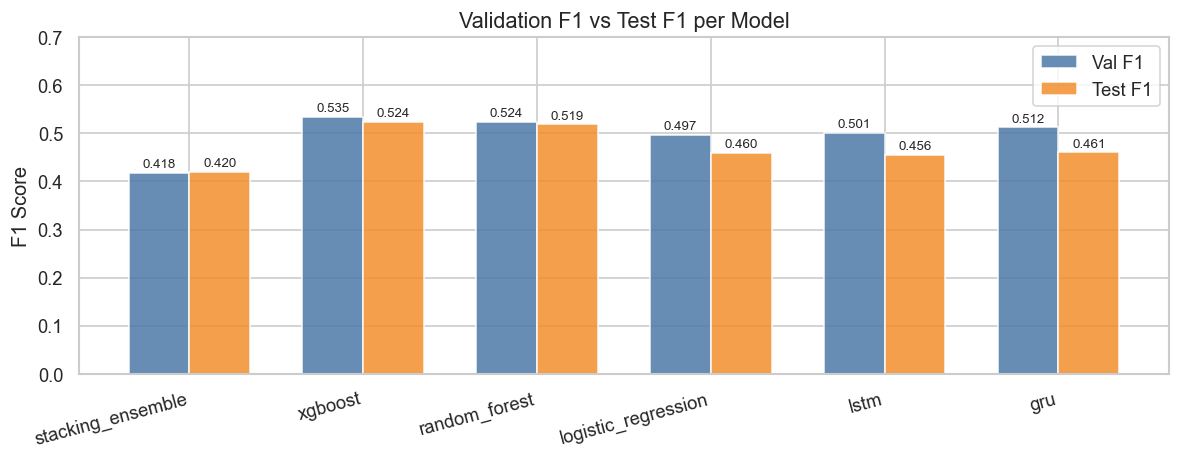

In [3]:
models_order = df["Model"].tolist()
x = np.arange(len(models_order))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
bars1 = ax.bar(x - w/2, df["val_f1"],  w, label="Val F1",  color="#4e79a7", alpha=0.85)
bars2 = ax.bar(x + w/2, df["test_f1"], w, label="Test F1", color="#f28e2b", alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(models_order, rotation=15, ha="right")
ax.set_ylabel("F1 Score")
ax.set_title("Validation F1 vs Test F1 per Model")
ax.legend()
ax.set_ylim(0, 0.70)
plt.tight_layout()
plt.show()

## 3 · All test metrics side-by-side

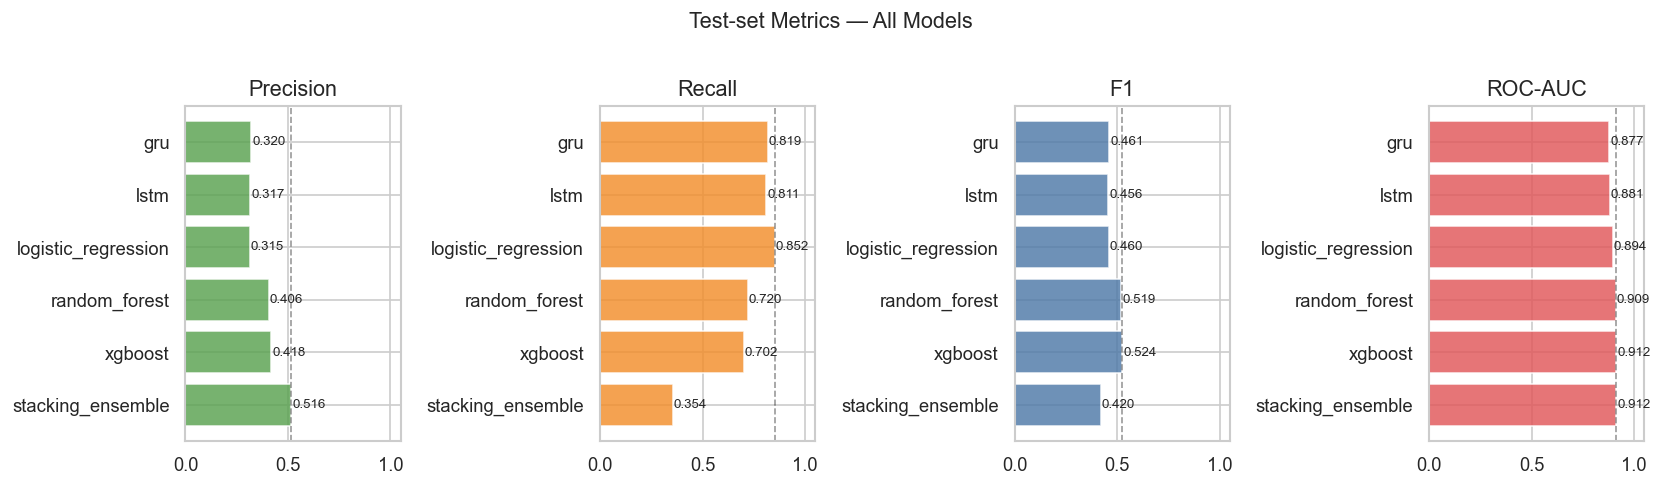

In [4]:
metrics = ["test_prec", "test_recall", "test_f1", "test_auc"]
metric_labels = ["Precision", "Recall", "F1", "ROC-AUC"]
colors = ["#59a14f", "#f28e2b", "#4e79a7", "#e15759"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)
for ax, col, label, color in zip(axes, metrics, metric_labels, colors):
    vals = df[col].values
    bars = ax.barh(df["Model"], vals, color=color, alpha=0.82)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                f"{v:.3f}", va="center", fontsize=8)
    ax.set_xlim(0, 1.05)
    ax.set_title(label)
    ax.axvline(vals.max(), color="black", lw=1, ls="--", alpha=0.4)

fig.suptitle("Test-set Metrics — All Models", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4 · Is validation F1 predictive of test AUC?

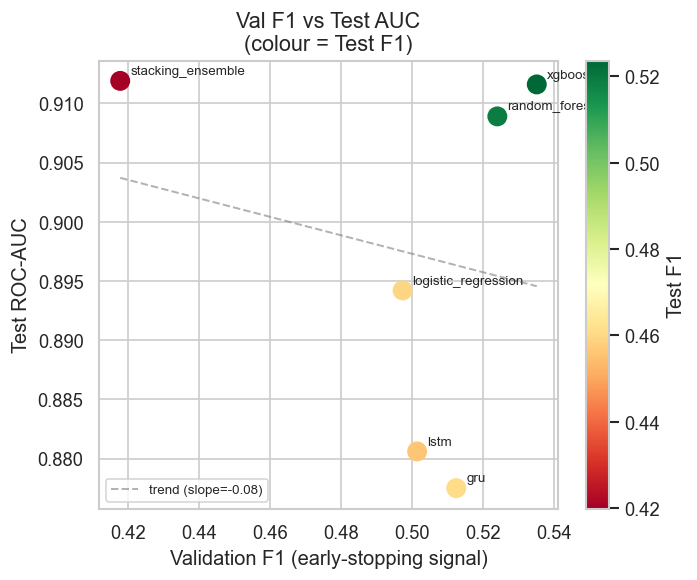

Pearson r(val_f1, test_auc) = -0.207


In [5]:
fig, ax = plt.subplots(figsize=(6, 5))

cmap = plt.cm.RdYlGn
sc = ax.scatter(df["val_f1"], df["test_auc"],
                c=df["test_f1"], cmap=cmap, s=120, zorder=5,
                vmin=df["test_f1"].min(), vmax=df["test_f1"].max())

for _, row in df.iterrows():
    ax.annotate(row["Model"], (row["val_f1"], row["test_auc"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

# Trend line
m, b = np.polyfit(df["val_f1"].dropna(), df["test_auc"].dropna(), 1)
xs = np.linspace(df["val_f1"].min(), df["val_f1"].max(), 100)
ax.plot(xs, m*xs + b, "--", color="grey", lw=1.2, alpha=0.6, label=f"trend (slope={m:.2f})")

plt.colorbar(sc, ax=ax, label="Test F1")
ax.set_xlabel("Validation F1 (early-stopping signal)")
ax.set_ylabel("Test ROC-AUC")
ax.set_title("Val F1 vs Test AUC\n(colour = Test F1)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

corr = df[["val_f1","test_auc"]].corr().iloc[0,1]
print(f"Pearson r(val_f1, test_auc) = {corr:.3f}")

## 5 · Radar chart — model profile

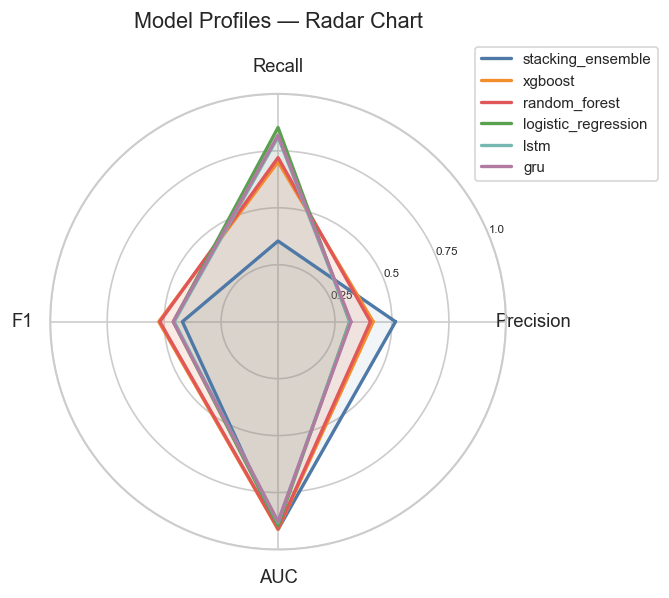

In [6]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

radar_metrics = ["test_prec", "test_recall", "test_f1", "test_auc"]
radar_labels  = ["Precision", "Recall", "F1", "AUC"]
N = len(radar_labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

palette = ["#4e79a7","#f28e2b","#e15759","#59a14f","#76b7b2","#b07aa1"]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for i, row in df.iterrows():
    vals = [row[m] for m in radar_metrics]
    vals += vals[:1]
    ax.plot(angles, vals, lw=2, color=palette[i % len(palette)], label=row["Model"])
    ax.fill(angles, vals, alpha=0.07, color=palette[i % len(palette)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25","0.5","0.75","1.0"], fontsize=7)
ax.set_title("Model Profiles — Radar Chart", pad=18, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12), fontsize=9)
plt.tight_layout()
plt.show()

## 6 · Logged hyperparameters

In [7]:
param_rows = []
for _, row in df.iterrows():
    p = {"Model": row["Model"]}
    p.update(row["params"])
    param_rows.append(p)

param_df = pd.DataFrame(param_rows).set_index("Model").fillna("—")
param_df.style.set_caption("Hyperparameters logged during training")

,base_models,meta_model,meta_C,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,best_iteration,min_samples_leaf,C,solver,class_weight,seq_len,hidden_size,num_layers,dropout,epochs,batch_size,lr
Model,,,,,,,,,,,,,,,,,,,,
stacking_ensemble,"xgboost,random_forest,lstm",logistic_regression,1.0,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—
xgboost,—,—,—,400,6,0.05,0.8,0.8,399,—,—,—,—,—,—,—,—,—,—,—
random_forest,—,—,—,300,12,—,—,—,—,5,—,—,—,—,—,—,—,—,—,—
logistic_regression,—,—,—,—,—,—,—,—,—,—,0.5,saga,balanced,—,—,—,—,—,—,—
lstm,—,—,—,—,—,—,—,—,—,—,—,—,—,10,64,2,0.3,30,256,0.001
gru,—,—,—,—,—,—,—,—,—,—,—,—,—,10,64,2,0.3,30,256,0.001


## 7 · Champion model

/var/folders/10/471w2rks2_g1vsz0bq3bm2_00000gn/T/ipykernel_24868/2819494089.py:28: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
/Users/apple/Desktop/Intelligent_Handover_Prediction_in_LTE_Networks_using_ML/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


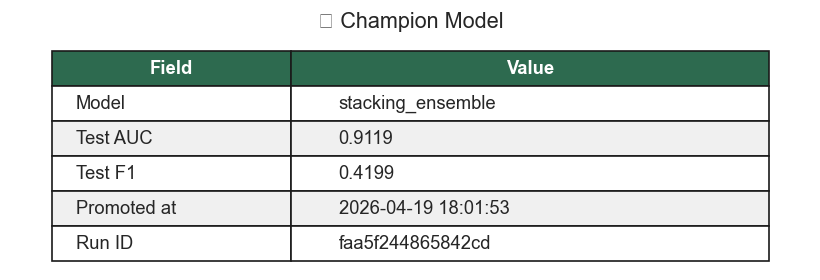

In [8]:
champion_path = ROOT / "models" / "champion" / "metadata.json"
with open(champion_path) as f:
    champ = json.load(f)

best_row = df[df["Model"] == champ["model_name"]].iloc[0]

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.axis("off")
info = [
    ["Model",       champ["model_name"]],
    ["Test AUC",    f"{champ['test_roc_auc']:.4f}"],
    ["Test F1",     f"{champ['test_f1']:.4f}"  if champ['test_f1'] else "—"],
    ["Promoted at", champ["promoted_at"][:19].replace("T"," ")],
    ["Run ID",      (champ.get("run_id") or "—")[:16]],
]
tbl = ax.table(cellText=info, colLabels=["Field","Value"],
               cellLoc="left", loc="center", colWidths=[0.3, 0.6])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2d6a4f")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#f0f0f0")
ax.set_title("🏆 Champion Model", fontsize=13, pad=10)
plt.tight_layout()
plt.show()